In [1]:
using ArgParse
using Dates
using JLD2
using Printf

using StatsBase
using Graphs
using SimpleWeightedGraphs
# using BlossomV
using GraphsMatching
using Plots

const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

InterruptException: InterruptException:

In [2]:
function adv_MWPM_sample(L::Int, T::Int, p::Float64)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        ρ = simple_correct(ρ)
        Ms[t+1] = magnetization(ρ)
    end

    return Ms
end

function adv_MWPM_sample(L::Int, T::Int, p::Float64, samples::Int)
    M1s = zeros(Float64, T+1)
    M2s = zeros(Float64, T+1)
    for i in 1:samples
        Ms = adv_MWPM_sample(L, T, p)
        M1s .+= Ms
        M2s .+= Ms.^2
    end
    M1s ./= samples
    M2s ./= samples
    return M1s, M2s
end

adv_MWPM_sample (generic function with 2 methods)

In [3]:
function simple_correct(ρ::AbstractMatrix)
    checks = measure(ρ, 0.0)
    
    horizontal_checks, vertical_checks = checks
    domain = track_domains((horizontal_checks, vertical_checks))
    if magnetization(domain) > 0.5
        domain = .!domain
    end
    
    return ρ .⊻ domain
end

simple_correct (generic function with 1 method)

In [4]:
L = 24
T = 10L
p = 0.42
samples = 10
M1s, _ = adv_MWPM_sample(L, T, p, 0.0, 0.0, samples)

MethodError: MethodError: no method matching adv_MWPM_sample(::Int64, ::Int64, ::Float64, ::Float64, ::Float64, ::Int64)
The function `adv_MWPM_sample` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  adv_MWPM_sample(::Int64, ::Int64, ::Float64, !Matched::Int64)
   @ Main ~/Code/single_shot/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:14
  adv_MWPM_sample(::Int64, ::Int64, ::Float64)
   @ Main ~/Code/single_shot/notebooks/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:1


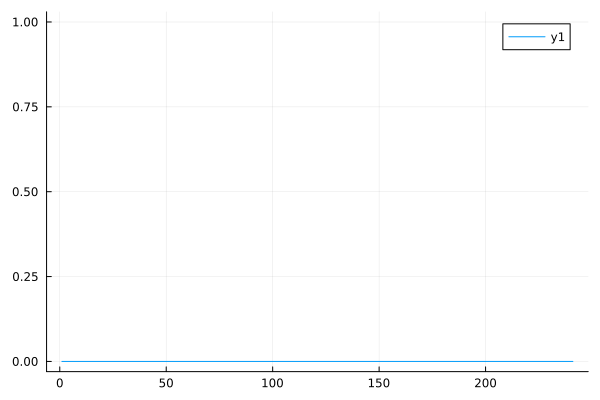

In [26]:
plot(M1s)